In [1]:
import numpy as np

from scipy.integrate import simpson,trapezoid
from scipy.special import sici
from scipy.optimize import curve_fit

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable, viridis
from matplotlib.colors import LogNorm
import matplotlib.cm as cm
from matplotlib.ticker import LogLocator

from astropy.io import fits

from halo_model_WL import *
%load_ext autoreload
%autoreload 2

In [2]:
c = cosmology()
hm = halo_model()
ps = power_spectrum(zmin=0,zmax=2,nz=64)

kmin = 1.00e-04 1/Mpc, kmax = 1.00e+03 1/Mpc
zmin = 0.00, zmax = 2.00
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)


/Users/user/Desktop/master_project/python_model/halo_model_WL.py:191: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  sigmaV_squared, _ = quad(lambda k: sigmaV_integrand(k, R, Pk), kmin, kmax, epsabs=0., epsrel=eps)


Computed Pmm using standard halo model


In [3]:
k_grid = ps.k
kmin = k_grid.min()
kmax = k_grid.max()

z_grid = ps.z_ps
zmin = z_grid.min()
zmax = z_grid.max()

nk = len(k_grid)
nz = len(z_grid)

k_mask = k_grid>1e-4

In [4]:
import hmcode
_,results = ps.camb_init()

kh_grid = k_grid / c.h 

P_HM_h = hmcode.power(kh_grid, z_grid[::-1], results,verbose=False)
P_HM_h = P_HM_h[::-1]

P_HM_interp = RegularGridInterpolator((z_grid,kh_grid*c.h),P_HM_h/c.h**3,bounds_error=False,fill_value=None)
P_HM = np.zeros((len(z_grid),len(k_grid)))
for i,z in enumerate(z_grid):
    P_HM[i,:] = P_HM_interp((z,k_grid))

Note: redshifts have been re-sorted (earliest first)


Note: redshifts have been re-sorted (earliest first)


In [5]:
P_HM_h_notweaks = hmcode.power(kh_grid, z_grid[::-1], results,verbose=False,tweaks=False)
P_HM_h_notweaks = P_HM_h_notweaks[::-1]

P_HM_notweaks_interp = RegularGridInterpolator((z_grid,kh_grid*c.h),P_HM_h_notweaks/c.h**3,bounds_error=False,fill_value=None)
P_HM_notweaks = np.zeros((len(z_grid),len(k_grid)))
for i,z in enumerate(z_grid):
    P_HM_notweaks[i,:] = P_HM_notweaks_interp((z,k_grid))

In [6]:
P_halofit_interp = ps.get_Pmm_interp_from_camb('takahashi')
P_halofit = P_halofit_interp(z_grid,k_grid)

In [7]:
pars,results=ps.camb_init()

Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)


In [8]:
import pyhalomodel as halo
Plin_interp = ps.Plin_interp

M_grid = np.logspace(1,18, 128)

# Halo model spectrum
Pk_hm = np.zeros((nz,nk))
Pk_hm_1h = np.zeros((nz,nk))
Pk_hm_2h = np.zeros((nz,nk))
for i, z in enumerate(z_grid):
    # Initialize
    hmod = halo.model(z, hm.OmegaM, name='Sheth & Tormen (1999)', Dv=200., dc=hm.dc_NakamuraSuto(hm.Om_at_z(z))) #H0=100 in pyhalomodel

    # Halo profiles
    R = hmod.Lagrangian_radius(M_grid)
    rv = hmod.virial_radius(M_grid)
    conc = hm.conc200(M_grid,z)
    Uk = hm.u_nfw(k_grid, rv/conc, conc) 
    matter_profile = halo.profile.Fourier(k_grid, M_grid, Uk, amplitude=M_grid, normalisation=hmod.rhom, mass_tracer=True)

    # Power spectra
    Pk_lin = Plin_interp(z,k_grid)
    sigmaM = hm.sigma_R(R, Plin_interp(z,k_grid), k_grid)
    Pk_2h, Pk_1h, Pk = hmod.power_spectrum(k_grid, Pk_lin, M_grid, sigmaM, {'m': matter_profile})
    Pk_hm[i,:] = Pk['m-m']
    Pk_hm_1h[i,:] = Pk_1h['m-m']
    Pk_hm_2h[i,:] = Pk_2h['m-m']

In [9]:
Plin = ps.Plin #linear

P_dict = ps.get_P_halomodel() #halo model like HMcode (tweaks)
Ps_dict = ps.get_P_halomodel_sashimi(subhalos=False) #halo model like SASHIMI (tweaks)

P_notweaks_dict = ps.get_P_halomodel(bloating=False,two_halo_suppression=False,transition_smoothing=False,B=4.) #halo model like HMcode without tweaks
Ps_notweaks_dict= ps.get_P_halomodel_sashimi(bloating=False,two_halo_suppression=False,transition_smoothing=False,subhalos=False,concentration_boost=False) #halo model like HMcode without tweaks

Ps_halomodel_dict = ps.get_P_halomodel_sashimi(two_halo_term='halomodel',subhalos=False) #simple halo model like Pyhalomodel
P_halomodel_dict = ps.get_P_halomodel(two_halo_term='halomodel') #simple halo model like SASHIMI

/Users/user/Desktop/master_project/python_model/halo_model_WL.py:191: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  sigmaV_squared, _ = quad(lambda k: sigmaV_integrand(k, R, Pk), kmin, kmax, epsabs=0., epsrel=eps)


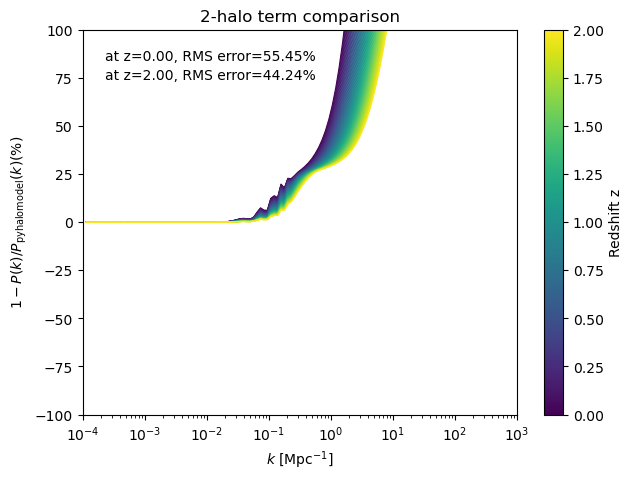

In [10]:
fig, ax = plt.subplots(figsize=(7,5))
ax.set_title('2-halo term comparison')
ax.set_xlabel(r'$k\ [{\rm Mpc}^{-1}]$')
ax.set_ylabel(r'$1-P(k)/P_{\rm pyhalomodel}(k)$(%)')
ax.set_xscale('log')
ax.set_yscale('linear')

P_reference = Pk_hm_2h
P_me = P_notweaks_dict['2h']

cmap = viridis
norm = Normalize(vmin=zmin, vmax=zmax)

for i,z in enumerate(z_grid):
    if i==0:
        rms = np.sqrt(np.mean((P_reference[i,:][k_mask]/P_me[i,:][k_mask]-1)**2))
        ax.text(0.05, 0.95, f'at z={z:.2f}, RMS error={rms:.2%}', transform=ax.transAxes, ha='left', va='top')
    if i==nz-1:
        rms = np.sqrt(np.mean((P_reference[i,:][k_mask]/P_me[i,:][k_mask]-1)**2))
        ax.text(0.05, 0.90, f'at z={z:.2f}, RMS error={rms:.2%}', transform=ax.transAxes, ha='left', va='top')
    ax.plot(k_grid[k_mask], 100.*(-1.+P_me[i,:][k_mask]/P_reference[i,:][k_mask]), color=cmap(norm(z)), lw=0.8)
plt.xlim(1e-4,kmax)
plt.ylim(-100,100)
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Redshift z')

plt.show()

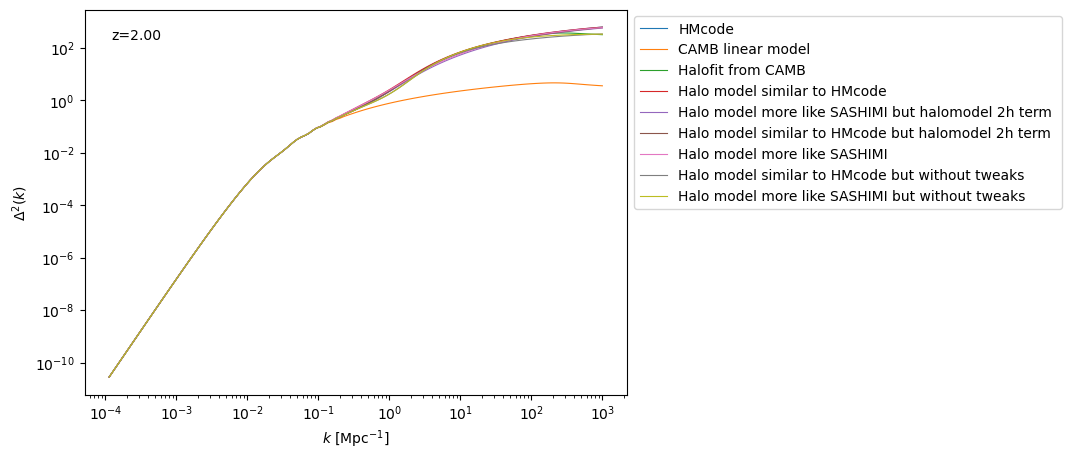

In [11]:
z_id=-1
k_mask = k_grid>1e-4
dim_factor = k_grid[k_mask]**3/(2.*np.pi**2)

fig, ax = plt.subplots(figsize=(7,5))
ax.set_xlabel(r'$k\ [{\rm Mpc}^{-1}]$')
ax.set_ylabel(r'$\Delta^2(k)$ ')
ax.set_xscale('log')
ax.set_yscale('log')

ax.plot(k_grid[k_mask], P_HM[z_id,:][k_mask]*dim_factor, color='C0', lw=0.8,label='HMcode')
ax.plot(k_grid[k_mask], Plin[z_id,:][k_mask]*dim_factor, color='C1', lw=0.8,label='CAMB linear model')
ax.plot(k_grid[k_mask], P_halofit[z_id,:][k_mask]*dim_factor, color='C2', lw=0.8,label='Halofit from CAMB')
ax.plot(k_grid[k_mask], P_dict['total'][z_id,:][k_mask]*dim_factor, color='C3', lw=0.8,label='Halo model similar to HMcode')
ax.plot(k_grid[k_mask], Ps_halomodel_dict['total'][z_id,:][k_mask]*dim_factor, color='C4', lw=0.8,label='Halo model more like SASHIMI but halomodel 2h term ')
ax.plot(k_grid[k_mask], P_halomodel_dict['total'][z_id,:][k_mask]*dim_factor, color='C5', lw=0.8,label='Halo model similar to HMcode but halomodel 2h term ')
ax.plot(k_grid[k_mask], Ps_dict['total'][z_id,:][k_mask]*dim_factor, color='C6', lw=0.8,label='Halo model more like SASHIMI')
ax.plot(k_grid[k_mask], P_notweaks_dict['total'][z_id,:][k_mask]*dim_factor, color='C7', lw=0.8,label='Halo model similar to HMcode but without tweaks')
ax.plot(k_grid[k_mask], Ps_notweaks_dict['total'][z_id,:][k_mask]*dim_factor, color='C8', lw=0.8,label='Halo model more like SASHIMI but without tweaks')
ax.text(0.05,0.95,f'z={z_grid[z_id]:.2f}',transform=ax.transAxes, ha='left', va='top')

ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

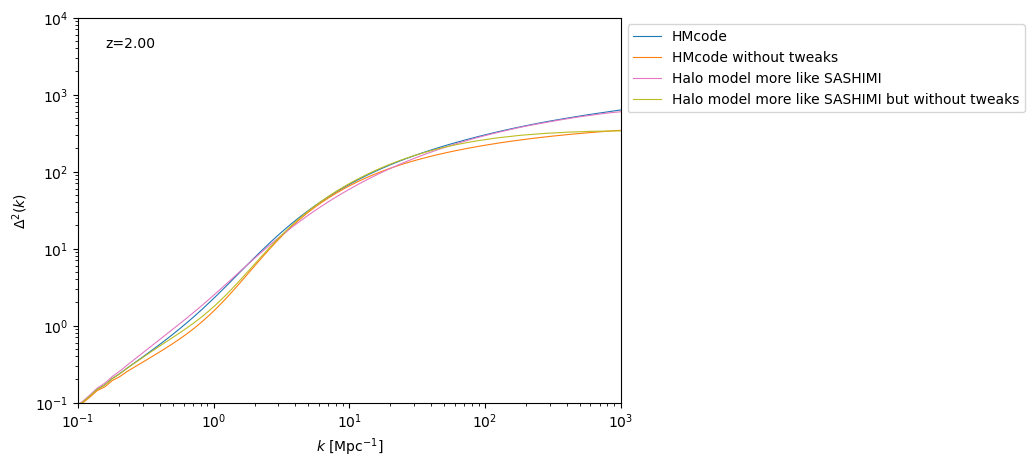

In [12]:
z_id=-1

k_mask = k_grid>1e-4
dim_factor = k_grid[k_mask]**3/(2.*np.pi**2)

fig, ax = plt.subplots(figsize=(7,5))
ax.set_xlabel(r'$k\ [{\rm Mpc}^{-1}]$')
ax.set_ylabel(r'$\Delta^2(k)$ ')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e-1,1e3)
ax.set_ylim(1e-1,1e4)

ax.plot(k_grid[k_mask], P_HM[z_id,:][k_mask]*dim_factor, color='C0', lw=0.8,label='HMcode')
ax.plot(k_grid[k_mask], P_HM_notweaks[z_id,:][k_mask]*dim_factor, color='C1', lw=0.8,label='HMcode without tweaks')

#ax.plot(k_grid[k_mask], P_halofit[z_id,:][k_mask]*dim_factor, color='C2', lw=0.8,label='Halofit from CAMB')

#ax.plot(k_grid[k_mask], P_dict['total'][z_id,:][k_mask]*dim_factor, color='C3', lw=0.8,label='Halo model similar to HMcode')
ax.plot(k_grid[k_mask], Ps_dict['total'][z_id,:][k_mask]*dim_factor, color='C6', lw=0.8,label='Halo model more like SASHIMI')

#ax.plot(k_grid[k_mask], Ps_halomodel_dict['total'][z_id,:][k_mask]*dim_factor, color='C4', lw=0.8,label='Halo model more like SASHIMI but halomodel 2h term ')
#ax.plot(k_grid[k_mask], P_halomodel_dict['total'][z_id,:][k_mask]*dim_factor, color='C5', lw=0.8,label='Halo model similar to HMcode but halomodel 2h term ')

#ax.plot(k_grid[k_mask], P_notweaks_dict['total'][z_id,:][k_mask]*dim_factor, color='C7', lw=0.8,label='Halo model similar to HMcode but without tweaks')
ax.plot(k_grid[k_mask], Ps_notweaks_dict['total'][z_id,:][k_mask]*dim_factor, color='C8', lw=0.8,label='Halo model more like SASHIMI but without tweaks')

ax.text(0.05,0.95,f'z={z_grid[z_id]:.2f}',transform=ax.transAxes, ha='left', va='top')

ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [13]:
P_dict = ps.get_P_halomodel(alpha_exp=1.603/1.036) #halo model like HMcode

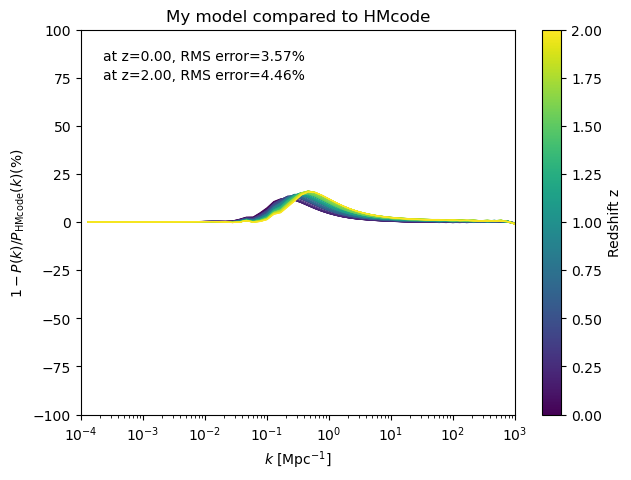

In [77]:
fig, ax = plt.subplots(figsize=(7,5))
ax.set_title('My model compared to HMcode')
ax.set_xlabel(r'$k\ [{\rm Mpc}^{-1}]$')
ax.set_ylabel(r'$1-P(k)/P_{\rm HMcode}(k)$(%)')
ax.set_xscale('log')
ax.set_yscale('linear')

P_reference = P_HM#_notweaks
P_me = P_dict['total']
#P_me = P_notweaks_dict['total']
#P_me = Ps_halomodel_dict['total']
#P_me = Ps_notweaks_dict['total']
#P_me = P_fit_dict['total']

cmap = viridis
norm = Normalize(vmin=zmin, vmax=zmax)

for i,z in enumerate(z_grid):
    if i==0:
        rms = np.sqrt(np.mean((P_reference[i,:][k_mask]/P_me[i,:][k_mask]-1)**2))
        ax.text(0.05, 0.95, f'at z={z:.2f}, RMS error={rms:.2%}', transform=ax.transAxes, ha='left', va='top')
    if i==nz-1:
        rms = np.sqrt(np.mean((P_reference[i,:][k_mask]/P_me[i,:][k_mask]-1)**2))
        ax.text(0.05, 0.90, f'at z={z:.2f}, RMS error={rms:.2%}', transform=ax.transAxes, ha='left', va='top')
    ax.plot(k_grid[k_mask], 100.*(-1.+P_me[i,:][k_mask]/P_reference[i,:][k_mask]), color=cmap(norm(z)), lw=0.8)
plt.xlim(1e-4,kmax)
plt.ylim(-100,100)
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Redshift z')

plt.show()

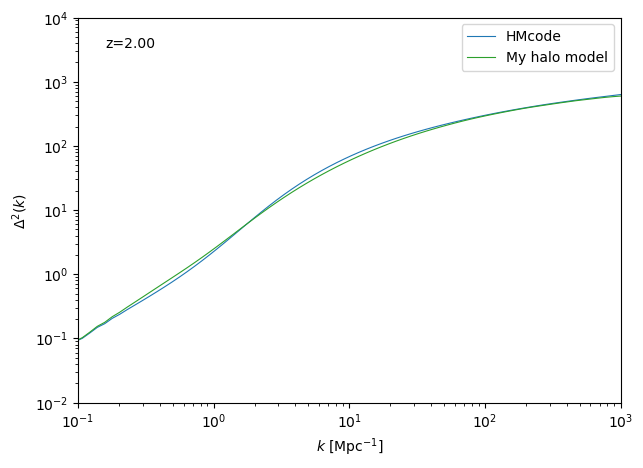

In [15]:
z_id=-1
k_mask = k_grid>1e-4
dim_factor = k_grid[k_mask]**3/(2.*np.pi**2)

fig, ax = plt.subplots(figsize=(7,5))
ax.set_xlabel(r'$k\ [{\rm Mpc}^{-1}]$')
ax.set_ylabel(r'$\Delta^2(k)$ ')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e-1,1e3)
ax.set_ylim(1e-2,1e4)

ax.plot(k_grid[k_mask], P_HM[z_id,:][k_mask]*dim_factor, color='C0', lw=0.8,label='HMcode')
#ax.plot(k_grid[k_mask], P_halofit[z_id,:][k_mask]*dim_factor, color='C1', lw=0.8,label='Halofit from CAMB')
ax.plot(k_grid[k_mask], Ps_dict['total'][z_id,:][k_mask]*dim_factor, color='C2', lw=0.8,label='My halo model')


ax.text(0.05,0.95,f'z={z_grid[z_id]:.2f}',transform=ax.transAxes, ha='left', va='top')

plt.legend()
plt.show()

In [16]:
ps.load_subhalo_data('pars.npz') #loads data from file and (re-)initializes a power spectrum class with the standard subhalo model power spectrum as default

kmin = 1.00e-04 1/Mpc, kmax = 1.00e+03 1/Mpc
zmin = 0.00, zmax = 2.00
Mmin = 1.00e+01 Msun, Mmax = 1.00e+18 Msun
min subhalo mass = 6.97e-01 Msun
max subhalo mass = 5.43e+17 Msun
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Computed Pmm using halo model with subhalos


In [17]:
k_grid = ps.k
kmin = k_grid.min()
kmax = k_grid.max()

z_grid = ps.z_ps
zmin = z_grid.min()
zmax = z_grid.max()

nk = len(k_grid)
nz = len(z_grid)

k_mask = k_grid>1e-4

In [18]:
Ps_subhalomodel_dict = ps.get_P_halomodel_sashimi(subhalos=True,DM_type='CDM') # subhalo halo model
Ps_subhalomodel_notweaks_dict = ps.get_P_halomodel_sashimi(bloating=False,two_halo_suppression=False,transition_smoothing=False,concentration_boost=False,two_halo_term='halomodel',subhalos=True,DM_type='CDM') # subhalo halo model
Ps_sub_dwg_dict = ps.get_P_halomodel_sashimi(bloating=False,two_halo_suppression=False,transition_smoothing=False,concentration_boost=False,two_halo_term='dewiggled',subhalos=True,DM_type='CDM') # subhalo halo model with HMcode 2h term
P_dict = ps.get_P_halomodel() #halo model like HMcode
Ps_dict = ps.get_P_halomodel_sashimi(subhalos=False) #halo model like SASHIMI
Ps_halomodel_dict = ps.get_P_halomodel_sashimi(two_halo_term='halomodel',subhalos=False) #simple halo model like Pyhalomodel
P_halomodel_dict = ps.get_P_halomodel(two_halo_term='halomodel') #simple halo model like SASHIMI
P_notweaks_dict = ps.get_P_halomodel(bloating=False,two_halo_suppression=False,transition_smoothing=False,B=4.) #halo model like HMcode without tweaks
Ps_notweaks_dict= ps.get_P_halomodel_sashimi(bloating=False,two_halo_suppression=False,transition_smoothing=False,subhalos=False,concentration_boost=False) #halo model like HMcode without tweaks


ValueError: x and y must have same first dimension, but have shapes (64,) and (50,)

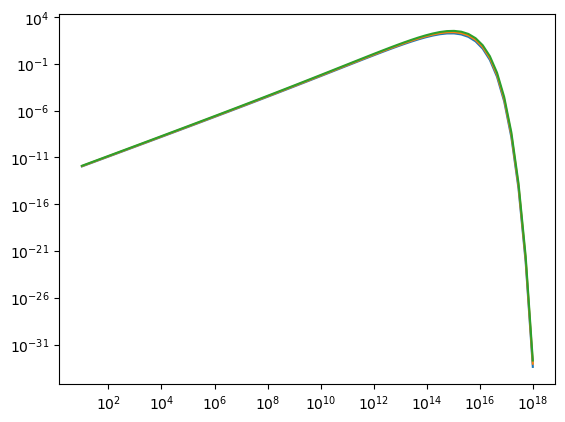

In [19]:
from sashimi_c import halo_model as halo_model_sashimi
hm_s = halo_model_sashimi()
z_grid = ps.z_ps
z_id=0
z=z_grid[z_id]

M_grid=ps.M_grid
R = ps.lagrangian_radius(M_grid)
lnM = np.log(M_grid)
deriv = np.zeros(len(R))
logR = np.log(R)
dc = hm_s.deltac_func(z)*hm.growthD(z)
sigmaM = hm_s.sigmaMz(M_grid,z) #different from HMcode
nu = dc/sigmaM
f_nu = ps.f_sheth_tormen(nu)
rhom=ps.rhom
Msm_grid = ps.Msm_grid[:,z_id]
logsigmaM = np.log(sigmaM)
for iR, _logR in enumerate(logR):
    deriv[iR] = 2.*ps.derivative_from_samples(_logR, logR, logsigmaM)
dnu_dlnm = -(nu/6.)*deriv
dndlnM = rhom/M_grid * f_nu * dnu_dlnm

integrand_ss =  (M_grid/rhom)**2 * dndlnM * (Msm_grid / M_grid)**2 
integrand_sc =  (M_grid/rhom)**2 * dndlnM * Msm_grid / M_grid
integrand_c = (M_grid/rhom)**2 * dndlnM

data=np.load('mass_function_check.npz') # From colossus dndlnM sheth-tormen mass function
M_grid_check = data['M']
Msm_grid_check = data['Ms']
rhom_check = data['rhom']
dndlnM_check = data['dndlnM']

integrand_ss_check =  (M_grid_check/rhom_check)**2 * dndlnM_check * (Msm_grid_check / M_grid_check)**2 
integrand_sc_check =  (M_grid_check/rhom_check)**2 * dndlnM_check * Msm_grid_check / M_grid_check
integrand_c_check = (M_grid_check/rhom_check)**2 * dndlnM_check

plt.loglog(M_grid,integrand_ss,label='integrand_ss',color='C0')
plt.loglog(M_grid,integrand_sc,label='integrand_sc',color='C1')
plt.loglog(M_grid,integrand_c,label='integrand_c',color='C2')

plt.loglog(M_grid,integrand_ss_check,label='integrand_ss_check)',color='C0',ls='--')
plt.loglog(M_grid,integrand_sc_check,label='integrand_sc_check)',color='C1',ls='--')
plt.loglog(M_grid,integrand_c_check,label='integrand_c_check',color='C2',ls='--')
plt.legend()

In [20]:
from sashimi_c import *
hm = halo_model()

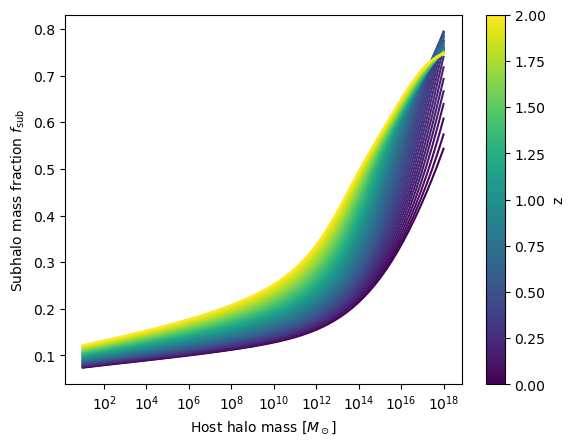

In [40]:
fig, ax = plt.subplots()

f_mz = ps.fsh_list
cmap = plt.cm.viridis
norm = Normalize(vmin=np.min(z_grid), vmax=np.max(z_grid))

for i, z in enumerate(z_grid):
    ax.plot(ps.M_grid, f_mz[:, i], color=cmap(norm(z)))

ax.set_xscale('log')
ax.set_xlabel(r'Host halo mass $[M_\odot]$')
ax.set_ylabel(r'Subhalo mass fraction $f_{\mathrm{sub}}$')

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('z')

plt.show()

In [ ]:
obs = subhalo_observables(
    M0_per_Msun=1e14,
    redshift=0,
    M0_at_redshift=False,
    #logmamin = -6#->0.214 Minimum value of subhalo mass at accretion defined as log_{10}(m_{min}/Msun). 
    #logmamin = 6#->0.194 Minimum value of subhalo mass at accretion defined as log_{10}(m_{min}/Msun). 
    logmamin = np.log10(1.73e10 / hm.h)#->0.150
)

In [75]:
print(obs.mass_fraction())

0.14984211072983875


In [70]:
w1 = obs.m0 * obs.weight       
m = np.sum(w1)
Mz = obs.Mzi(1e14,0)
print(m/Mz)

0.21401089560486836


In [55]:
n_values = [0,1,2,3]

sh = subhalo_properties()

list_za  = np.arange(0.,7.,0.1)
ma_max   = sh.Mzi(1.e16,list_za)
list_ma  = np.logspace(-5,np.log10(ma_max/sh.Msun),22).T*sh.Msun

for n in n_values:
    print(f"Running for n = {n}")
    for i,za in enumerate(list_za):
        print(za)
        print(np.log10(list_ma[i]/sh.Msun))
        for j,ma in enumerate(list_ma[i]):
            sh    = subhalo_observables(ma/sh.Msun,za,M0_at_redshift=True)
            fsh   = sh.mass_fraction()
            Bsh,_ = sh.annihilation_boost_factor(n=n)

            print(za,np.log10(ma/sh.Msun),fsh,Bsh)

Running for n = 0
0.0
[-5. -4. -3. -2. -1.  0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12.
 13. 14. 15. 16.]
0.0 -5.0 0.0 0.0
0.0 -4.0 0.029270831570561495 0.14505192908439726
0.0 -3.0 0.044019158450969445 0.22806022636424247
0.0 -2.0 0.05396836103811666 0.28807755612804453
0.0 -1.0 0.061634490627173605 0.33621407961290484
0.0 0.0 0.06804356413567923 0.3779914465338362
0.0 1.0 0.07372803772204287 0.4172200365913078
0.0 2.0 0.07901423049552535 0.4571395487234921
0.0 3.0 0.08412635501388951 0.5008993628619964
0.0 4.0 0.08922945787244625 0.551874762500142
0.0 5.0 0.09445081785853467 0.6139884158313883
0.0 6.0 0.09989691297231879 0.6921378161494431
0.0 7.0 0.1056782573727983 0.7927671805250035
0.0 8.0 0.11196241545290758 0.924719586832943
0.0 9.0 0.11907396669667827 1.1002642930437962
0.0 10.0 0.12766675517312248 1.3360811504903003
0.0 11.0 0.138956563370558 1.653050896242475
0.0 12.0 0.15496537487351145 2.0725288863080653
0.0 13.0 0.17868081250770707 2.605430124766748
0.0 14.0 0.21401

KeyboardInterrupt: 

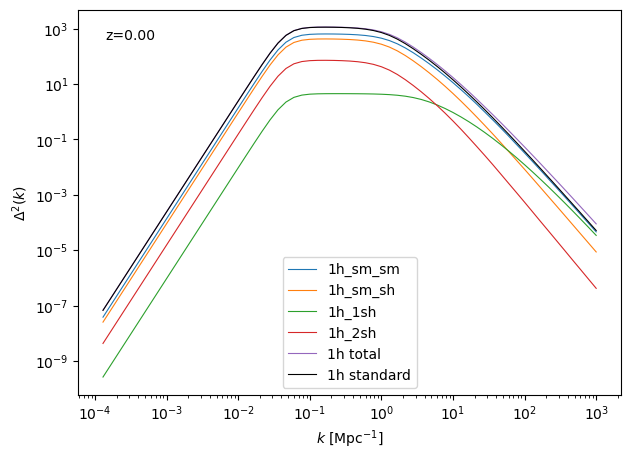

In [76]:
P = Ps_sub_dwg_dict
P_1h = P['1h']
P_sm_sm = P['1h_sm_sm']
P_sm_sh = P['1h_sm_sh']
P_1sh = P['1h_1sh']
P_2sh = P['1h_2sh']

z_id=0
k_mask = k_grid>1e-4
dim_factor = 1# k_grid[k_mask]**3/(2.*np.pi**2)

fig, ax = plt.subplots(figsize=(7,5))
ax.set_xlabel(r'$k\ [{\rm Mpc}^{-1}]$')
ax.set_ylabel(r'$\Delta^2(k)$ ')
ax.set_xscale('log')
ax.set_yscale('log')

ax.plot(k_grid[k_mask], P_sm_sm[z_id,:][k_mask]*dim_factor, color='C0', lw=0.8,label='1h_sm_sm')
ax.plot(k_grid[k_mask], P_sm_sh[z_id,:][k_mask]*dim_factor, color='C1', lw=0.8,label='1h_sm_sh')
ax.plot(k_grid[k_mask], P_1sh[z_id,:][k_mask]*dim_factor, color='C2', lw=0.8,label='1h_1sh')
ax.plot(k_grid[k_mask], P_2sh[z_id,:][k_mask]*dim_factor, color='C3', lw=0.8,label='1h_2sh')
ax.plot(k_grid[k_mask], P_1h[z_id,:][k_mask]*dim_factor, color='C4', lw=0.8,label='1h total')
ax.plot(k_grid[k_mask], Ps_notweaks_dict['1h'][z_id,:][k_mask]*dim_factor, color='black', lw=0.8,label='1h standard')
ax.text(0.05,0.95,f'z={z_grid[z_id]:.2f}',transform=ax.transAxes, ha='left', va='top')

plt.legend()
plt.show()

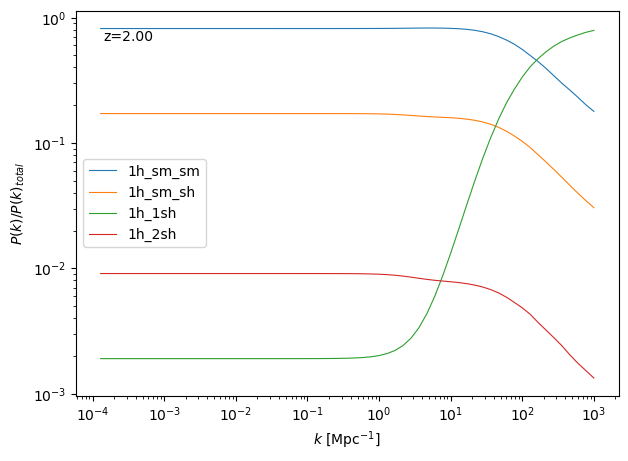

In [26]:
z_id=-1
k_mask = k_grid>1e-4

fig, ax = plt.subplots(figsize=(7,5))
ax.set_xlabel(r'$k\ [{\rm Mpc}^{-1}]$')
ax.set_ylabel(r'$P(k)/P(k)_{total}$ ')
ax.set_xscale('log')
ax.set_yscale('log')

ax.plot(k_grid[k_mask], P_sm_sm[z_id,:][k_mask]/P_1h[z_id,:][k_mask], color='C0', lw=0.8,label='1h_sm_sm')
ax.plot(k_grid[k_mask], P_sm_sh[z_id,:][k_mask]/P_1h[z_id,:][k_mask], color='C1', lw=0.8,label='1h_sm_sh')
ax.plot(k_grid[k_mask], P_1sh[z_id,:][k_mask]/P_1h[z_id,:][k_mask], color='C2', lw=0.8,label='1h_1sh')
ax.plot(k_grid[k_mask], P_2sh[z_id,:][k_mask]/P_1h[z_id,:][k_mask], color='C3', lw=0.8,label='1h_2sh')
ax.text(0.05,0.95,f'z={z_grid[z_id]:.2f}',transform=ax.transAxes, ha='left', va='top')

plt.legend()
plt.show()

In [27]:
P_HM = np.zeros((nz,nk))
for i,z in enumerate(z_grid):
    P_HM[i,:] = P_HM_interp((z,k_grid))

In [28]:
P_halofit_interp = ps.get_Pmm_interp_from_camb('takahashi')
P_halofit = P_halofit_interp(z_grid,k_grid)

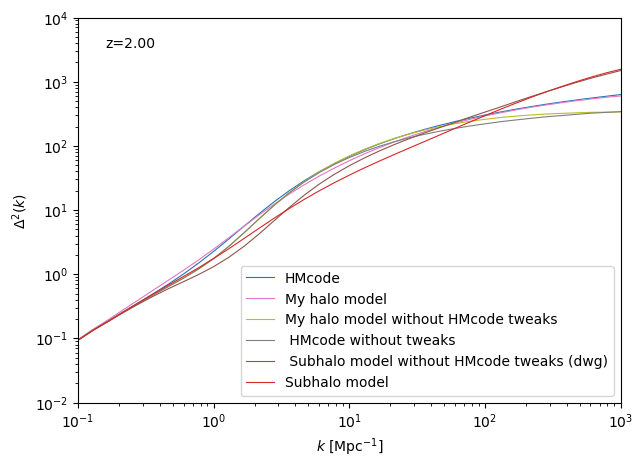

In [29]:
z_id=-1
k_mask = k_grid>1e-4
dim_factor = k_grid[k_mask]**3/(2.*np.pi**2)

fig, ax = plt.subplots(figsize=(7,5))
ax.set_xlabel(r'$k\ [{\rm Mpc}^{-1}]$')
ax.set_ylabel(r'$\Delta^2(k)$ ')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e-1,1e3)
ax.set_ylim(1e-2,1e4)

ax.plot(k_grid[k_mask], P_HM[z_id,:][k_mask]*dim_factor, color='C0', lw=0.8,label='HMcode')
ax.plot(k_grid[k_mask], Ps_dict['total'][z_id,:][k_mask]*dim_factor, color='C6', lw=0.8,label='My halo model')
ax.plot(k_grid[k_mask], Ps_notweaks_dict['total'][z_id,:][k_mask]*dim_factor, color='C8', lw=0.8,label='My halo model without HMcode tweaks')
ax.plot(k_grid[k_mask], P_notweaks_dict['total'][z_id,:][k_mask]*dim_factor, color='C7', lw=0.8,label=' HMcode without tweaks')
ax.plot(k_grid[k_mask], Ps_sub_dwg_dict['total'][z_id,:][k_mask]*dim_factor, color='C5', lw=0.8,label=' Subhalo model without HMcode tweaks (dwg)')

#ax.plot(k_grid[k_mask], P_halofit[z_id,:][k_mask]*dim_factor, color='C2', lw=0.8,label='Halofit')
ax.plot(k_grid[k_mask], Ps_subhalomodel_dict['total'][z_id,:][k_mask]*dim_factor, color='C3', lw=0.8,label='Subhalo model')
#ax.plot(k_grid[k_mask], Ps_subhalomodel_notweaks_dict['total'][z_id,:][k_mask]*dim_factor, color='C1', lw=0.8,label='Subhalo model without HMcode tweaks')
ax.text(0.05,0.95,f'z={z_grid[z_id]:.2f}',transform=ax.transAxes, ha='left', va='top')

plt.legend()
plt.show()

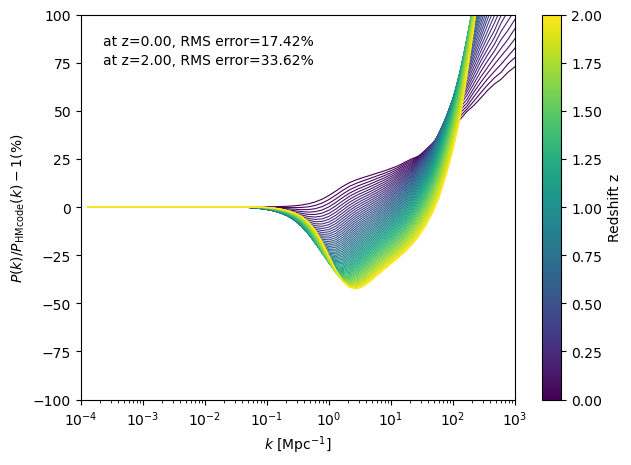

In [30]:
fig, ax = plt.subplots(figsize=(7,5))
ax.set_xlabel(r'$k\ [{\rm Mpc}^{-1}]$')
ax.set_ylabel(r'$P(k)/P_{\rm HMcode}(k)-1$(%)')
ax.set_xscale('log')
ax.set_yscale('linear')

#P_reference = P_HM
#P_reference = Ps_dict['total']
P_reference = Ps_notweaks_dict['total']
#P_me = Ps_subhalomodel_dict['total']
#P_me = Ps_dict['total']
P_me = Ps_sub_dwg_dict['total']

cmap = viridis
norm = Normalize(vmin=zmin, vmax=zmax)

for i,z in enumerate(z_grid):
    if i==0:
        rms = np.sqrt(np.mean((P_reference[i,:][k_mask]/P_me[i,:][k_mask]-1)**2))
        ax.text(0.05, 0.95, f'at z={z:.2f}, RMS error={rms:.2%}', transform=ax.transAxes, ha='left', va='top')
    if i==nz-1:
        rms = np.sqrt(np.mean((P_reference[i,:][k_mask]/P_me[i,:][k_mask]-1)**2))
        ax.text(0.05, 0.90, f'at z={z:.2f}, RMS error={rms:.2%}', transform=ax.transAxes, ha='left', va='top')
    ax.plot(k_grid[k_mask], 100.*(-1.+P_me[i,:][k_mask]/P_reference[i,:][k_mask]), color=cmap(norm(z)), lw=0.8)
plt.xlim(1e-4,kmax)
plt.ylim(-100,100)
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Redshift z')

plt.show()

In [31]:
hdufid = fits.open('data/sim_3x2_fiducial_nla.fits')
cls_fid = hdufid['galaxy_shear_cl'].data

hdudes = fits.open('data/2pt_NG_final_2ptunblind_02_24_21_wnz_redmagic_covupdate.fits')

data_source = hdudes['nz_source'].data[:-1]
data_lens = hdudes['nz_lens'].data[:-1]

header_source = hdudes['nz_source'].header
header_lens = hdudes['nz_lens'].header

#redshift bins Redmagic
z_lims = np.array([0.15,0.35,0.5,0.65,0.8,0.9])

bin_number_source = 4
zs = np.array(data_source['Z_MID'])
zs_bins = []
zs_means = []
nz_source_dict = {}
ngal_source_dict = {}
sige_source_dict = {}
for i in range(bin_number_source):
    z = zs[(zs >= z_lims[i]) & (zs < z_lims[i+1])]
    zs_bins.append(np.array(z))
    zs_means.append(np.mean(z))
    nz_source_dict[i] = data_source['BIN' + str(i+1)]
    ngal_source_dict[i] = header_source['NGAL_' + str(i+1)] * (60 * 180 / np.pi)**2 # gal/arcmin^2  -> gal/str
    sige_source_dict[i] = header_source['SIG_E_' + str(i+1)]


bin_number_lens = 5
zl = np.array(data_lens['Z_MID'])
zl_bins = []
zl_means = []
nz_lens_dict = {}
ngal_lens_dict = {}
for i in range(bin_number_lens):
    z = zl[(zl >= z_lims[i]) & (zl < z_lims[i+1])]
    zl_bins.append(np.array(z))
    zl_means.append(np.mean(z))
    nz_lens_dict[i] = data_lens['BIN' + str(i+1)]
    ngal_lens_dict[i] = header_lens['NGAL_' + str(i+1)] * (60 * 180 / np.pi)**2 # gal/arcmin^2  -> gal/str

#Biases REDMAGIC
galaxy_bias = np.array([1.7, 1.7, 1.7, 2.0, 2.0])  # lens galaxy bias for each lens bin
magnification_bias = np.array([1.3134, -0.5179, 0.3372, 2.2515, 1.9667])  # magnification bias for each lens bin
shear_calibration_bias = np.array([-0.0063,-0.0198,-0.0241,-0.0369])  # shear calibration bias for each source bin

#redshift shift for lens galaxsssies REDMAGIC
shift_params = np.array([0.006,0.001,0.004,-0.002,-0.007])
stretch_params = np.array([1,1,1,1,1.23])

#Intrinsic Alignment (IA)
IA_params = np.array([0.7,-1.36,-1.7,-2.5,1.0,0.62]) #a1,a2,alf1,alfa2,bTA,z0
C1_mean=5e-14 # h^2 Msun^-1 Mpc^3

ells = np.loadtxt("data/ang_sqrt.txt")

In [32]:
aps_halomodel = angular_power_spectrum(model = 'halomodel')

kmin = 1.00e-04 1/Mpc, kmax = 1.00e+03 1/Mpc
zmin = 0.01, zmax = 2.00
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Computed Pmm using standard halo model


In [33]:
aps_subhalomodel = angular_power_spectrum(model = 'subhalomodel',file_dir='subhalo_params100.npz',DM_type='CDM')

kmin = 1.00e-05 1/Mpc, kmax = 1.00e+03 1/Mpc
zmin = 0.01, zmax = 2.00
Mmin = 1.00e+06 Msun, Mmax = 1.00e+16 Msun
min subhalo mass = 8.22e+04 Msun
max subhalo mass = 3.30e+15 Msun
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Computed Pmm using halo model with subhalos


In [34]:
aps_halofit = angular_power_spectrum(model = 'takahashi')

kmin = 1.00e-04 1/Mpc, kmax = 1.00e+03 1/Mpc
zmin = 0.01, zmax = 2.00
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Computed Pmm using CAMB non-linear model takahashi


In [35]:
name = 'halomodel'
aps = aps_halomodel

cls_gk = np.zeros((5,4,len(ells)))
cls_gI = np.zeros((5,4,len(ells)))
cls_muI = np.zeros((5,4,len(ells)))
cls_muk = np.zeros((5,4,len(ells)))
cls_gg = np.zeros((5,4,len(ells)))
cls_kk = np.zeros((5,4,len(ells)))           
#i for lens, j for source
for i in range(5):
    for j in range(4):
            nz_source = nz_source_dict[j]
            shear = shear_calibration_bias[j] if shear_calibration_bias is not None else 0

            nz_lens = nz_lens_dict[i]   
            zl_mean = zl_means[i]         
            shift_lens = shift_params[i] if shift_params is not None else 0
            stretch_lens = stretch_params[i] if stretch_params is not None else 1
            gb = galaxy_bias[i]
            mb = magnification_bias[i]

            NLA = True

            cls_gk[i,j,:] = aps.cls_gk(l_bins=ells, galaxy_bias=gb, zl=zl, zs=zs, nz_lens=nz_lens, nz_source=nz_source, zl_mean=zl_mean, nz_lens_stretch=stretch_lens, nz_lens_shift=shift_lens,shear=shear)
            cls_gI[i,j,:] = aps.cls_gI(l_bins=ells,zl=zl, zs=zs, nz_lens=nz_lens, nz_source=nz_source, zl_mean=zl_mean, nz_lens_stretch = stretch_lens,  nz_lens_shift = shift_lens,NLA=NLA)
            cls_muI[i,j,:] = aps.cls_muI(l_bins=ells,zl=zl, zs=zs, nz_lens=nz_lens, nz_source=nz_source, zl_mean=zl_mean,magnification_bias=mb, nz_lens_stretch = stretch_lens,  nz_lens_shift = shift_lens,NLA=NLA)
            cls_muk[i,j,:] = aps.cls_muk(l_bins=ells,galaxy_bias=gb,zl=zl, zs=zs, nz_lens=nz_lens, nz_source=nz_source, zl_mean=zl_mean,magnification_bias=mb,nz_lens_stretch = stretch_lens,  nz_lens_shift = shift_lens, shear=shear)
            cls_kk[i,j,:] = aps.cls_kk(l_bins=ells, zs=zs, nz_source=nz_source, shear=shear)
            cls_gg[i,j,:] = aps.cls_gg(l_bins=ells, galaxy_bias=gb, zl=zl, nz_lens=nz_lens, zl_mean=zl_mean, nz_lens_stretch=stretch_lens, nz_lens_shift=shift_lens)

In [36]:
np.savez('Cls_'+name+'.npz', cls_gk=cls_gk, cls_gI=cls_gI, cls_muI=cls_muI, cls_muk=cls_muk, cls_gg=cls_gg, cls_kk=cls_kk,ells = ells)

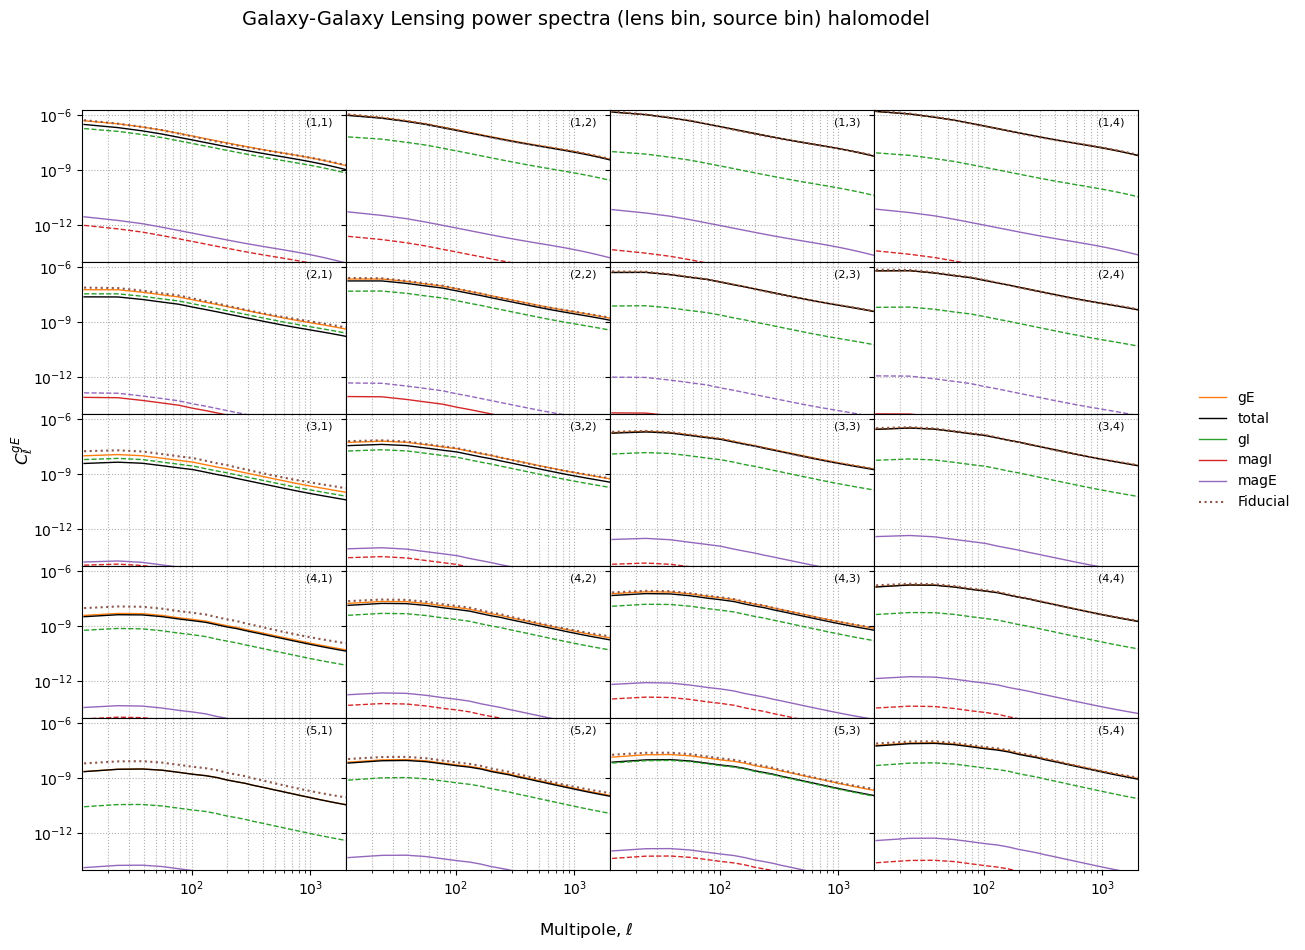

In [37]:
n_lens, n_source = 5, 4
fig, axes = plt.subplots(
    n_lens, n_source,
    figsize=(12, 10),
    sharex=True,
    sharey=True
)

for i in range(n_lens):
    for j in range(n_source):

        ax = axes[i, j]

        # Main spectra
        ax.plot(ells, cls_gk[i, j, :], color='C1', lw=1, label='gE')
        ax.plot(ells, cls_gk[i, j, :]+cls_muI[i, j, :]+cls_muk[i, j, :]+cls_gI[i, j, :], color='black', lw=1, label='total')

        ax.plot(ells[cls_gI[i, j, :] < 0], -cls_gI[i, j, :][cls_gI[i, j, :] < 0], linestyle='--',color='C2', lw=1)
        ax.plot(ells, cls_gI[i, j, :], linestyle='-',color='C2', lw=1, label='gI')

        ax.plot(ells[cls_muI[i, j, :] < 0], -cls_muI[i, j, :][cls_muI[i, j, :] < 0], linestyle='--',color='C3', lw=1)
        ax.plot(ells, cls_muI[i, j, :], linestyle='-',color='C3', lw=1, label='magI')

        ax.plot(ells[cls_muk[i, j, :] < 0], -cls_muk[i, j, :][cls_muk[i, j, :] < 0], linestyle='--',color='C4', lw=1)
        ax.plot(ells, cls_muk[i, j, :], linestyle='-',color='C4', lw=1, label='magE')

        cl_fid = np.array([cls_fid['VALUE'][x] for x in range(len(cls_fid)) if cls_fid['BIN1'][x]==i+1 and cls_fid['BIN2'][x]==j+1])
        l_bins_fid = np.array([cls_fid['ANG'][x] for x in range(len(cls_fid)) if cls_fid['BIN1'][x]==i+1 and cls_fid['BIN2'][x]==j+1])
        ax.plot(l_bins_fid, cl_fid,color='C5', linestyle=':', label='Fiducial')



        # Bin label
        ax.text(
            0.95, 0.95, f"({i+1},{j+1})",
            transform=ax.transAxes,
            ha="right", va="top", fontsize=8
        )

        ax.set_xscale("log")
        ax.set_yscale("log")

        ax.set_xlim(12,ells.max())
        ax.set_ylim(9e-15,2e-6)

        # Grid (shared visually because axes are shared)
        ax.grid(True, which="both", ls=":")

        ax.yaxis.set_major_locator(LogLocator(numticks=4))
        ax.xaxis.set_major_locator(LogLocator(numticks=3))


# Shared axis labels
fig.supxlabel(r"Multipole, $\ell$", fontsize=12)
fig.supylabel(r"$C_{\ell}^{gE}$", fontsize=12)

fig.suptitle(
    'Galaxy-Galaxy Lensing power spectra (lens bin, source bin) '+name+'',
    fontsize=14,
    y=0.94
)

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles, labels,
    loc='center left',
    ncol=1,
    frameon=False,
    bbox_to_anchor=(1.0, 0.5)  # <-- right of the plot
)


plt.subplots_adjust(
    wspace=0.0, hspace=0.0,
    top=0.84,   # lowered to make room for legend
    bottom=0.08,
    left=0.08,
    right=0.96
)

plt.show()